In [1]:
import pandas as pd

df = pd.read_csv("data/superstore.csv")

df.head()
df.shape
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [2]:
df.shape

(9800, 18)

In [3]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [5]:
df = df.dropna(subset=["Postal Code"])

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [7]:
df["Sales"].sum()

np.float64(2252607.4127)

In [8]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64

In [9]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       710219.6845
East       660589.3560
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

In [10]:
df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [14]:
df["Order Date"].head()

0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
Name: Order Date, dtype: datetime64[ns]

<Axes: xlabel='Order Date'>

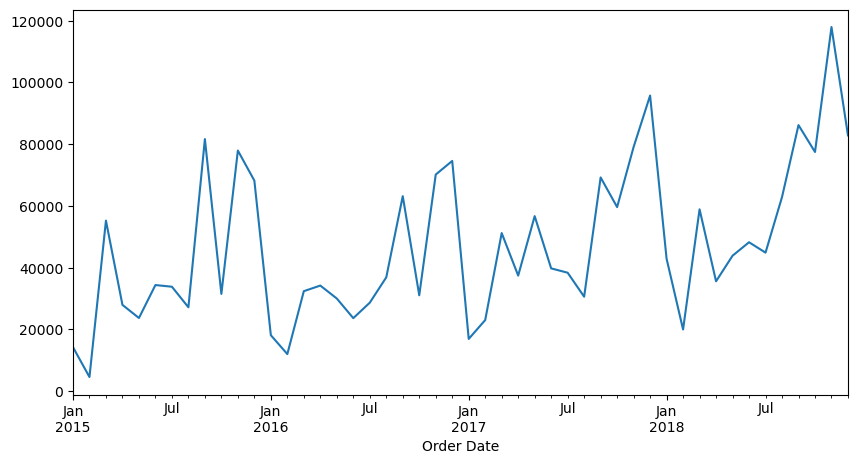

In [15]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.plot(figsize=(10,5))

In [16]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)